# Inference Batch — Year-wise Mining Detection
**Notebook:** `inference_batch.ipynb`

Runs the same inference pipeline as `inference_visualizer.ipynb` but loops through
every JP2 file year by year automatically.

### What it saves (per year, best scene selected)
```
inference_output/temporal/
  2021_overlay.png          ← satellite + red highlights
  2021_heatmap.png          ← probability heatmap
  2021_result.json          ← mining stats (area, patches, coverage %)
  2022_overlay.png
  2022_heatmap.png
  2022_result.json
  ... (one set per year)
  all_years_results.csv     ← combined table for temporal analysis
```

**Then run `temporal_analysis.ipynb`** which reads these results and makes charts.


## Cell 1 — Imports

In [1]:
import os, glob, re, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

try:
    import rasterio
    from rasterio.transform import xy as rio_xy
    from rasterio.crs import CRS
    from rasterio.enums import Resampling
    HAS_RASTERIO = True
    print('rasterio OK')
except ImportError:
    HAS_RASTERIO = False
    print('rasterio not found — install: pip install rasterio')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))


rasterio OK
Device: cuda
GPU   : NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2 — Config
> **Only update `DATA_ROOT`** — everything else is auto-detected.

In [2]:
# ── Folder containing your year subfolders ───────────────────────────────
DATA_ROOT = r"R:\ai project image\data image big"

# ── Year folder names → year labels ──────────────────────────────────────
YEAR_MAP = {
    'big 2021' : 2021,
    '2022'     : 2022,
    '2023'     : 2023,
    '2024'     : 2024,
    '2025'     : 2025,
}

# ── Model ─────────────────────────────────────────────────────────────────
MODEL_PATH  = 'saved_models/best_model.pth'
NUM_CLASSES = 2

# ── Patch settings ────────────────────────────────────────────────────────
PATCH_SIZE  = 64      # must match training patch size
STRIDE      = 32      # 50% overlap
THRESHOLD   = 0.6     # raised from 0.5 → reduces false positives on large scenes
BATCH_SIZE  = 64

# ── Sentinel-2 native resolution ─────────────────────────────────────────
NATIVE_RES_M = 10.0   # metres per pixel at native resolution
# IMPORTANT: area is computed using the NATIVE resolution, not the downsampled one.
# load_jp2 returns the scale factor so we can correct for downsampling.
# patch area = (PATCH_SIZE * native_res / scale) ** 2 in m², converted to km²
# But simpler: count mining pixels in the mask, multiply by (native_res)^2.
# We use: area_km2 = (mining_pixels_in_mask * (NATIVE_RES_M/scale)^2) / 1e6

# ── Output ────────────────────────────────────────────────────────────────
OUTPUT_DIR  = 'inference_output/temporal'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Scene selection ───────────────────────────────────────────────────────
# Use MEDIAN not max_mining — median across scenes in a year is more stable
# and not skewed by one unusually clear/cloudy acquisition.
SCENE_SELECT = 'median'  # options: 'median', 'max_mining', 'first'

MAX_DIM = 15000  # Set high to prevent downsampling and preserve CNN spatial resolution!

print(f'Data root  : {DATA_ROOT}')
print(f'Model      : {MODEL_PATH}')
print(f'Output     : {OUTPUT_DIR}')
print(f'Patch size : {PATCH_SIZE}px  Stride: {STRIDE}px  Threshold: {THRESHOLD}')
print(f'Native res : {NATIVE_RES_M}m/px')

for folder, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    path  = os.path.join(DATA_ROOT, folder)
    files = glob.glob(os.path.join(path, '*.jp2'))
    status = f'{len(files)} JP2 files' if files else 'NOT FOUND'
    print(f'  {year} ({folder}): {status}')


Data root  : R:\ai project image\data image big
Model      : saved_models/best_model.pth
Output     : inference_output/temporal
Patch size : 64px  Stride: 32px  Threshold: 0.6
Native res : 10.0m/px
  2021 (big 2021): 6 JP2 files
  2022 (2022): 6 JP2 files
  2023 (2023): 6 JP2 files
  2024 (2024): 4 JP2 files
  2025 (2025): 5 JP2 files


## Cell 3 — Load Model

In [3]:
def load_efficientnet_b0(model_path):
    """Load EfficientNet-B0 — matches your training setup exactly."""
    model = models.efficientnet_b0(weights=None)
    in_f  = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_f, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, NUM_CLASSES)
    )
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.to(device).eval()
    print(f'Model loaded: {model_path}')
    return model

model = load_efficientnet_b0(MODEL_PATH)

# Transform — resize patch to 224x224 for EfficientNet
patch_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
print('Patch transform ready.')


Model loaded: saved_models/best_model.pth
Patch transform ready.


## Cell 4 — Core Functions
(Same logic as inference_visualizer.ipynb — just packaged as reusable functions)

In [4]:
def load_jp2(path, max_dim=MAX_DIM):
    """Load a Sentinel-2 JP2/GeoTIFF at native resolution, return RGB uint8.
    No colour stretching — raw pixel values match training data exactly.
    """
    if HAS_RASTERIO:
        with rasterio.open(path) as src:
            h, w = src.height, src.width
            scale = min(1.0, max_dim / max(h, w))
            nh, nw = int(h * scale), int(w * scale)
            data = src.read(
                out_shape=(src.count, nh, nw),
                resampling=Resampling.bilinear
            )
            geo_transform = src.transform
            crs = src.crs
        # (bands, H, W) → (H, W, 3) — NO percentile stretch, raw uint8
        data = np.moveaxis(data[:3], 0, -1).astype(np.uint8)
        return data, geo_transform, crs, scale
    else:
        img = Image.open(path).convert('RGB')
        img.thumbnail((max_dim, max_dim))
        return np.array(img), None, None, 1.0


def _resize_for_display(arr, max_side=5000):
    """Downsample array to max_side px on longest side — for PNG output only.
    Inference and statistics are always computed at full resolution.
    """
    h, w = arr.shape[:2]
    scale = min(1.0, max_side / max(h, w))
    if scale >= 1.0:
        return arr
    nh, nw = int(h * scale), int(w * scale)
    if arr.ndim == 2:
        # prob_map float32 — scale to uint8, resize, scale back
        img = Image.fromarray((arr * 255).clip(0, 255).astype(np.uint8))
        img = img.resize((nw, nh), Image.BILINEAR)
        return np.array(img).astype(np.float32) / 255.0
    else:
        img = Image.fromarray(arr)
        img = img.resize((nw, nh), Image.BILINEAR)
        return np.array(img)


def run_inference(img_rgb, patch_size=PATCH_SIZE, stride=STRIDE,
                  threshold=THRESHOLD, batch_size=BATCH_SIZE):
    """
    Sliding window inference on full-resolution image. Returns:
      prob_map    : (H,W) float32 — mining probability per pixel
      mining_mask : (H,W) bool    — True where mining detected
      detections  : list of {pixel_y, pixel_x, confidence}
      n_total     : total patches scanned
    """
    H, W = img_rgb.shape[:2]
    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)
    detections = []

    positions = [(y, x)
                 for y in range(0, H - patch_size + 1, stride)
                 for x in range(0, W - patch_size + 1, stride)]

    patches_buf, pos_buf = [], []

    with torch.no_grad():
        for i, (y, x) in enumerate(positions):
            patch = img_rgb[y:y+patch_size, x:x+patch_size]
            patches_buf.append(patch_transform(Image.fromarray(patch)))
            pos_buf.append((y, x))

            flush = (len(patches_buf) == batch_size) or (i == len(positions)-1)
            if flush and patches_buf:
                batch = torch.stack(patches_buf).to(device)
                probs = torch.softmax(model(batch), dim=1)[:, 0].cpu().numpy()

                for (py, px), prob in zip(pos_buf, probs):
                    prob_map [py:py+patch_size, px:px+patch_size] += prob
                    count_map[py:py+patch_size, px:px+patch_size] += 1
                    if prob >= threshold:
                        detections.append({'pixel_y': py, 'pixel_x': px,
                                           'confidence': float(prob)})
                patches_buf, pos_buf = [], []

            if (i+1) % 1000 == 0 or i == len(positions)-1:
                pct = (i+1)/len(positions)*100
                print(f'  {pct:5.1f}%  |  {i+1:,}/{len(positions):,} patches'
                      f'  |  mining so far: {len(detections):,}')

    count_map = np.maximum(count_map, 1)
    prob_map  = prob_map / count_map
    return prob_map, prob_map >= threshold, detections, len(positions)


def make_overlay(img_rgb, mining_mask):
    """Red overlay on detected mining pixels."""
    overlay = img_rgb.copy().astype(np.float32)
    overlay[mining_mask, 0] = np.clip(overlay[mining_mask, 0]*0.4 + 255*0.6, 0, 255)
    overlay[mining_mask, 1] = np.clip(overlay[mining_mask, 1]*0.4,            0, 255)
    overlay[mining_mask, 2] = np.clip(overlay[mining_mask, 2]*0.4,            0, 255)
    return overlay.astype(np.uint8)


def save_overlay_fig(img_rgb, overlay, mining_mask, detections,
                     year, date_str, out_path):
    """Save side-by-side original vs overlay figure (downsampled for rendering)."""
    coverage = mining_mask.sum() / mining_mask.size * 100
    # Downsample for matplotlib rendering only (saves ~3 GB RAM)
    img_disp     = _resize_for_display(img_rgb,  max_side=5000)
    overlay_disp = _resize_for_display(overlay,  max_side=5000)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_disp)
    axes[0].set_title(f'Original - {year} ({date_str})', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(overlay_disp)
    axes[1].set_title(f'Mining Detection - threshold={THRESHOLD}', fontsize=12)
    axes[1].axis('off')
    red_p  = mpatches.Patch(color='red',  alpha=0.7, label='Mining detected')
    gray_p = mpatches.Patch(color='gray', alpha=0.5, label='Non-mining')
    axes[1].legend(handles=[red_p, gray_p], loc='lower right', fontsize=10)
    axes[1].text(0.02, 0.98,
                 f'Coverage: {coverage:.1f}%\nDetections: {len(detections):,}',
                 transform=axes[1].transAxes, fontsize=10, va='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.suptitle(f'Illegal Mining Detection - {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved overlay: {out_path}')


def save_heatmap_fig(img_rgb, prob_map, year, out_path):
    """Save heatmap figure (downsampled for rendering)."""
    # Downsample for matplotlib rendering only (saves ~3 GB RAM)
    img_disp  = _resize_for_display(img_rgb,  max_side=5000)
    prob_disp = _resize_for_display(prob_map, max_side=5000)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_disp)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    im = axes[1].imshow(prob_disp, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[1].set_title('Mining Confidence Heatmap', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
                 label='Mining Probability')
    plt.suptitle(f'Confidence Heatmap - {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved heatmap : {out_path}')

print('All functions defined.')


All functions defined.


## Cell 5 — Run Inference Year by Year

This loops through every year folder, processes every JP2, picks the best scene, and saves outputs.


  Year 2021  |  6 JP2 file(s)

  [20210226] T45QUE_20210226T044741_TCI_10m.jp2
  Image size: 10980x10980 px  (scale=1.000)
    0.9%  |  1,000/116,964 patches  |  mining so far: 23
    1.7%  |  2,000/116,964 patches  |  mining so far: 52
    2.6%  |  3,000/116,964 patches  |  mining so far: 77
    3.4%  |  4,000/116,964 patches  |  mining so far: 100
    4.3%  |  5,000/116,964 patches  |  mining so far: 117
    5.1%  |  6,000/116,964 patches  |  mining so far: 142
    6.0%  |  7,000/116,964 patches  |  mining so far: 168
    6.8%  |  8,000/116,964 patches  |  mining so far: 189
    7.7%  |  9,000/116,964 patches  |  mining so far: 203
    8.5%  |  10,000/116,964 patches  |  mining so far: 230
    9.4%  |  11,000/116,964 patches  |  mining so far: 253
   10.3%  |  12,000/116,964 patches  |  mining so far: 266
   11.1%  |  13,000/116,964 patches  |  mining so far: 275
   12.0%  |  14,000/116,964 patches  |  mining so far: 286
   12.8%  |  15,000/116,964 patches  |  mining so far: 296
   

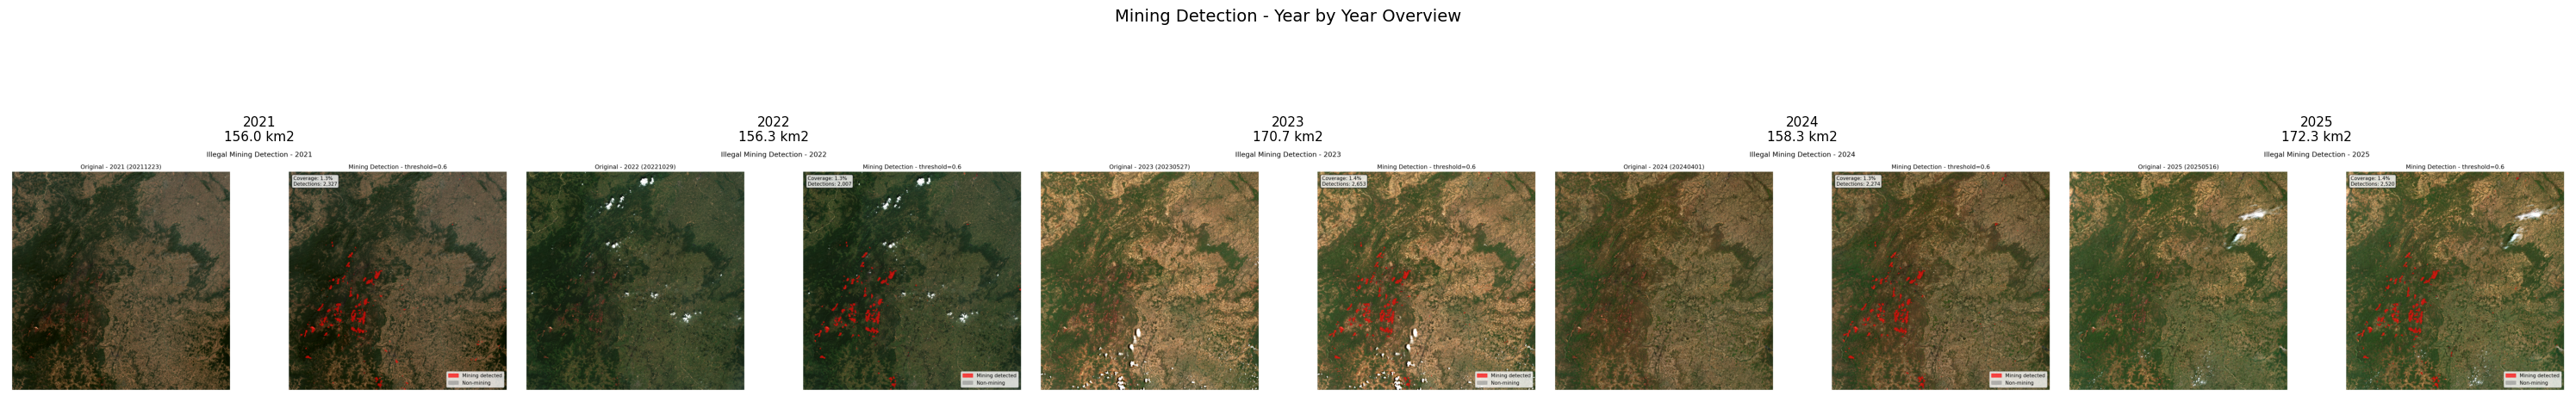

Saved: inference_output/temporal\all_years_overview.png


In [5]:
yearly_results = []   # one dict per year (best scene)
all_scenes     = []   # one dict per JP2 file (all scenes)

for folder_name, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    folder_path = os.path.join(DATA_ROOT, folder_name)
    jp2_files   = sorted(glob.glob(os.path.join(folder_path, '*.jp2')))

    if not jp2_files:
        print(f'\n{year}: no JP2 files found in {folder_path} - skipping')
        continue

    print(f'\n{"="*60}')
    print(f'  Year {year}  |  {len(jp2_files)} JP2 file(s)')
    print(f'{"="*60}')

    year_scenes = []
    seen_dates = set()

    for jp2_path in jp2_files:
        fname      = os.path.basename(jp2_path)
        date_match = re.search(r'_(\d{8})T', fname)
        date_str   = date_match.group(1) if date_match else 'unknown'
        if date_str in seen_dates and date_str != "unknown":
            print(f"  [SKIPPED] Duplicate date detected: {date_str}")
            continue
        seen_dates.add(date_str)
        
        if date_str != "unknown" and int(date_str[:4]) != year:
            print(f"  [SKIPPED] File year ({date_str[:4]}) does not match folder year ({year})")
            continue
        print(f'\n  [{date_str}] {fname}')

        try:
            # ── Load image (native resolution, no colour stretching) ──────
            img_rgb, geo_tf, crs, scale = load_jp2(jp2_path)
            H, W = img_rgb.shape[:2]
            print(f'  Image size: {W}x{H} px  (scale={scale:.3f})')

            # ── Run inference at full resolution ──────────────────────────
            prob_map, mining_mask, detections, n_total = run_inference(img_rgb)

            n_mining      = len(detections)
            coverage      = mining_mask.sum() / mining_mask.size * 100
            pixel_size_m  = NATIVE_RES_M / scale
            mining_pixels = int(mining_mask.sum())
            area_km2      = (mining_pixels * pixel_size_m**2) / 1e6

            print(f'  Result: {n_mining:,} mining patches  |  {area_km2:.2f} km2  |  {coverage:.2f}% coverage')

            # ── Save arrays to temp disk (prevents RAM accumulation) ──────
            temp_f = os.path.join(OUTPUT_DIR, f'{year}_{date_str}_temp.npz')
            np.savez_compressed(temp_f, img=img_rgb, prob=prob_map, mask=mining_mask)

            # ── FREE RAM immediately after saving to disk ─────────────────
            del img_rgb, prob_map, mining_mask
            import gc; gc.collect()

            scene = {
                'year'        : year,
                'date'        : date_str,
                'filename'    : fname,
                'n_mining'    : n_mining,
                'n_total'     : n_total,
                'area_km2'    : area_km2,
                'coverage_pct': coverage,
                '_detections' : detections,
                '_temp_file'  : temp_f,
            }
            year_scenes.append(scene)
            all_scenes.append(scene)

        except Exception as e:
            print(f'  ERROR: {e}')
            import traceback; traceback.print_exc()

    if not year_scenes:
        continue

    # ── Pick best scene for this year ─────────────────────────────────
    if SCENE_SELECT == 'max_mining':
        best = max(year_scenes, key=lambda s: s['area_km2'])
    elif SCENE_SELECT == 'median':
        areas_list = [s['area_km2'] for s in year_scenes]
        median_val = sorted(areas_list)[len(areas_list)//2]
        best = min(year_scenes, key=lambda s: abs(s['area_km2'] - median_val))
    else:
        best = year_scenes[0]

    print(f'\n  Best scene for {year}: {best["date"]} ({best["area_km2"]:.2f} km2)')

    # ── Reload ONLY the best scene arrays from disk ───────────────────
    with np.load(best['_temp_file']) as data:
        best_img  = data['img']
        best_prob = data['prob']
        best_mask = data['mask']

    # ── Save overlay + heatmap ────────────────────────────────────────
    overlay = make_overlay(best_img, best_mask)

    save_overlay_fig(
        best_img, overlay, best_mask,
        best['_detections'], year, best['date'],
        os.path.join(OUTPUT_DIR, f'{year}_overlay.png')
    )
    save_heatmap_fig(
        best_img, best_prob, year,
        os.path.join(OUTPUT_DIR, f'{year}_heatmap.png')
    )

    # ── Free the reloaded arrays ───────────────────────────────────────
    del best_img, best_prob, best_mask, overlay
    import gc; gc.collect()

    # ── Save per-year JSON result ─────────────────────────────────────
    result_dict = {k: v for k, v in best.items() if not k.startswith('_')}
    json_path = os.path.join(OUTPUT_DIR, f'{year}_result.json')
    with open(json_path, 'w') as jf:
        json.dump(result_dict, jf, indent=2)

    yearly_results.append(result_dict)

    # ── Clean up all temp .npz files for this year ────────────────────
    for temp_file in glob.glob(os.path.join(OUTPUT_DIR, f'{year}_*_temp.npz')):
        try: os.remove(temp_file)
        except: pass

print(f'\n{"="*60}')
print(f'  BATCH INFERENCE COMPLETE')
print(f'  Years processed: {len(yearly_results)}')
print(f'  Total JP2 files: {len(all_scenes)}')
print(f'{"="*60}')

# ── All scenes CSV ────────────────────────────────────────────────────────
df_all = pd.DataFrame([
    {k: v for k, v in s.items() if not k.startswith('_')}
    for s in all_scenes
])
df_all = df_all.sort_values(['year','date']).reset_index(drop=True)

all_csv = os.path.join(OUTPUT_DIR, 'all_scenes_results.csv')
df_all.to_csv(all_csv, index=False)
print(f'All scenes saved: {all_csv}')
print(df_all[['year','date','n_mining','area_km2','coverage_pct']].to_string(index=False))

# ── Best-per-year CSV ─────────────────────────────────────────────────────
df_best = pd.DataFrame(yearly_results).sort_values('year').reset_index(drop=True)
df_best['change_km2'] = df_best['area_km2'].diff()
df_best['change_pct'] = df_best['area_km2'].pct_change() * 100

best_csv = os.path.join(OUTPUT_DIR, 'yearly_summary.csv')
df_best.to_csv(best_csv, index=False)
print(f'\nYearly summary saved: {best_csv}')

print(f'\n{"="*55}')
print(f'  YEAR-WISE SUMMARY')
print(f'{"="*55}')
print(f'{"Year":<6} {"Date":<10} {"Patches":<10} {"Area km2":<12} {"Change"}')
print('-'*55)
for _, row in df_best.iterrows():
    chg = (f"{row['change_km2']:+.2f} km2 ({row['change_pct']:+.1f}%)"
           if pd.notna(row.get('change_km2')) and pd.notna(row.get('change_pct'))
           else 'baseline')
    print(f"{int(row['year']):<6} {row['date']:<10} "
          f"{int(row['n_mining']):<10} {row['area_km2']:<12.2f} {chg}")
print('='*55)

print(f'\nAll outputs saved to: {OUTPUT_DIR}/')
print('Now run temporal_analysis.ipynb to generate charts.')

if yearly_results:
    n = len(yearly_results)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]
    for ax, res in zip(axes, yearly_results):
        img_path = os.path.join(OUTPUT_DIR, f'{res["year"]}_overlay.png')
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path))
            ax.set_title(f'{res["year"]}\n{res["area_km2"]:.1f} km2', fontsize=11)
        ax.axis('off')
    plt.suptitle('Mining Detection - Year by Year Overview', fontsize=14)
    plt.tight_layout()
    overview_path = os.path.join(OUTPUT_DIR, 'all_years_overview.png')
    plt.savefig(overview_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {overview_path}')


## Cell 6 — Save Combined CSV

Saves all results to a single CSV that `temporal_analysis.ipynb` will read.

## Cell 7 — Quick Preview: All Overlay Maps Side by Side